# LAB 7. Moving Beyond Linearity

In [33]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score,train_test_split,KFold
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from scipy import stats
from ISLP import load_data

## | 7.6

In [2]:
data = load_data("Wage")

data

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154
...,...,...,...,...,...,...,...,...,...,...,...
2995,2008,44,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,2. >=Very Good,1. Yes,5.041393,154.685293
2996,2007,30,2. Married,1. White,2. HS Grad,2. Middle Atlantic,1. Industrial,2. >=Very Good,2. No,4.602060,99.689464
2997,2005,27,2. Married,2. Black,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.193125,66.229408
2998,2005,27,1. Never Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,2. >=Very Good,1. Yes,4.477121,87.981033


In [22]:
X = data[['age']]
y = data['wage']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42)

X_train

,age
611,28
530,25
2787,32
49,33
1883,55
...,...
1638,53
1095,61
1130,28
1294,51


In [30]:
kf = KFold(n_splits=10,shuffle=True,random_state=42)

cv_scores = []
cv_stds = []
degrees = range(1,11)

for d in degrees:
    poly = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=True)),
        ('linear', LinearRegression())
    ])

    scores = cross_val_score(
        poly,
        X_train,
        y_train,
        cv=kf,
        scoring='neg_mean_squared_error'
    )

    mse = -scores.mean()
    print(f"Degree: {d} | MSE: {mse}")

    cv_scores.append(mse)
    cv_stds.append(scores.std())

Degree: 1 | MSE: 1727.479653633371
Degree: 2 | MSE: 1650.4229865286245
Degree: 3 | MSE: 1644.1790969667213
Degree: 4 | MSE: 1643.8111894337756
Degree: 5 | MSE: 1647.2393615982296
Degree: 6 | MSE: 1647.0914607703603
Degree: 7 | MSE: 1645.209632883186
Degree: 8 | MSE: 1646.0228156881712
Degree: 9 | MSE: 1648.6314321450493
Degree: 10 | MSE: 1654.412781358288
Degree: 10 | MSE: 1654.412781358288


In [31]:
optimal_degree = degrees[np.argmin(cv_scores)]

min_mse = min(cv_scores)

print(f"Optimal degree: {optimal_degree} | MSE: {min_mse}")

Optimal degree: 4 | MSE: 1643.8111894337756


In [39]:
models = {}
predictions = {}
rss_values = {}

for d in degrees:
    poly = Pipeline([
        ('poly',PolynomialFeatures(degree=d,include_bias=True)),
        ('linear',LinearRegression())
    ])

    poly.fit(X_train,y_train)
    models[d] = poly

    y_hat = poly.predict(X_test)
    predictions[d] = y_hat

    rss = np.sum((y_test - y_hat)**2)
    rss_values[d] = rss

In [35]:
# ANOVA 

rss_prev = rss_values[1]
df_residual_prev = len(y_test) - 2

for d in range(2,11):
    rss_curr = rss_values[d]
    df_added = 1
    df_residual_curr = len(y_test) - (d + 1)

    f_stat = ((rss_prev - rss_curr) / df_added) / (rss_curr / df_residual_curr)
    p_value = 1 - stats.f.cdf(f_stat,df_added,df_residual_curr)

    print(f"{d} | {rss_curr} | {f_stat} | {p_value}")

    rss_prev = rss_curr

2 | 1335451.5294540464 | 45.23729079266684 | 3.1058045024678904e-11
3 | 1335620.2279006997 | -0.11317124811665442 | 1.0
4 | 1332192.2754373723 | 2.3029839695405823 | 0.12947884802872578
5 | 1333201.3847633 | -0.6766747677354962 | 1.0
6 | 1330868.2595849056 | 1.5655049020073615 | 0.21118869627217762
7 | 1329398.6392730966 | 0.9860859484935399 | 0.3209701802401421
8 | 1329562.249405142 | -0.10964257425150609 | 1.0
9 | 1329733.93384843 | -0.11490956997999875 | 1.0
10 | 1329674.3915900874 | 0.03980904498219174 | 0.8419000297739632


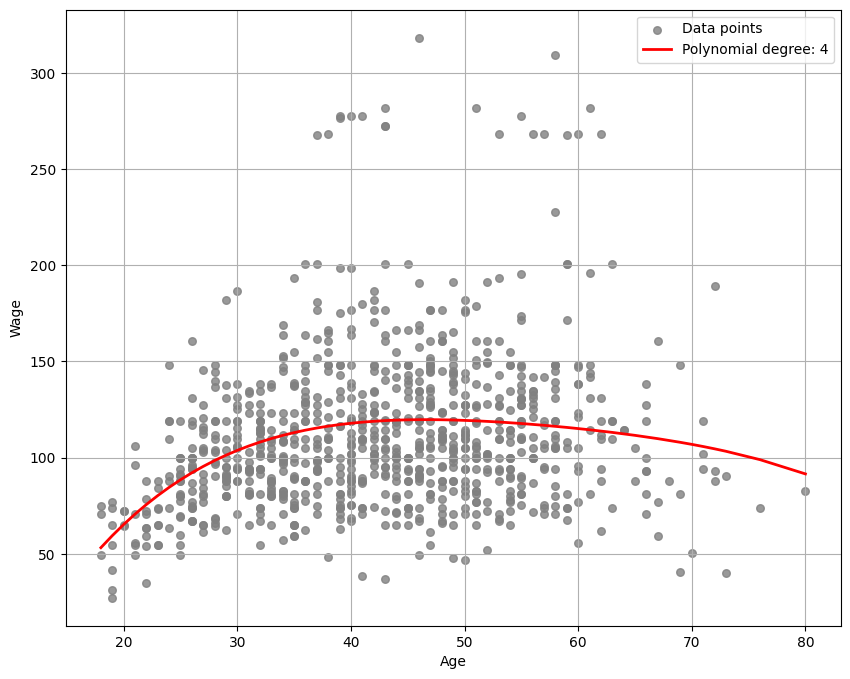

In [41]:
plt.figure(figsize=(10,8))

plt.scatter(X_test,y_test,alpha=0.8, color='gray', s=30, label='Data points')

preds = predictions[optimal_degree]

# Sort by X values for smooth line
sort_idx = np.argsort(X_test.values.flatten())
X_test_sorted = X_test.values[sort_idx]
preds_sorted = preds[sort_idx]

plt.plot(X_test_sorted, preds_sorted, 'r-', linewidth=2, label=f"Polynomial degree: {optimal_degree}")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.legend()
plt.grid(True)
plt.show()

## Optimal number of Cuts

In [43]:
from sklearn.preprocessing import KBinsDiscretizer

In [54]:
n_cuts_range = range(1,11)
cv_scores2 = []
models2 = []

kf2 = KFold(n_splits=10, shuffle=True)

for n_cuts in n_cuts_range:
    n_bins = n_cuts + 1

    pipe = Pipeline([
        ('Kbins', KBinsDiscretizer(n_bins=n_bins,encode='onehot',strategy='uniform')),
        ('linear',LinearRegression())
    ])

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv = kf2,
        scoring='neg_mean_squared_error'
    )

    cv_scores2.append(-scores.mean())
    models2.append(pipe)

In [55]:
optimal_idx = np.argmin(cv_scores2)

optimal_cuts = n_cuts_range[optimal_idx]

optimal_cuts

10

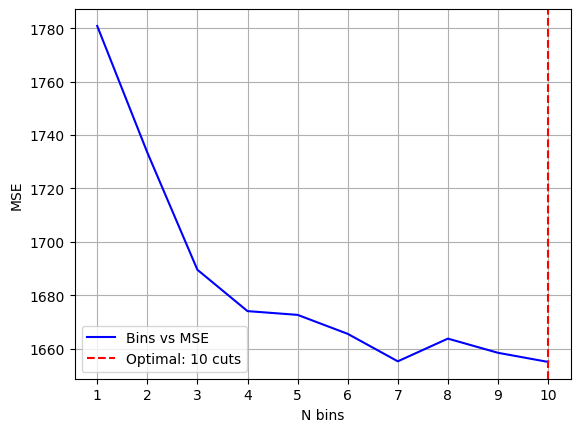

In [56]:
plt.plot(n_cuts_range,cv_scores2,'b-',label="Bins vs MSE")
plt.axvline(x=optimal_cuts,color='red',linestyle='--',label=f"Optimal: {optimal_cuts} cuts")
plt.legend()
plt.xlabel("N bins")
plt.ylabel("MSE")
plt.xticks(n_cuts_range)
plt.grid(True)
plt.show()